# Olympic Games: 120 Years of Athletic Excellence & Medal Prediction

#### -------------------------------------------------------------------------------------------------------------------------------------

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_events = pd.read_csv("athlete_events.csv")
df_noc = pd.read_csv("noc_regions.csv")

In [3]:
print(f"Events Dataset Shape: {df_events.shape}")
print(f"NOC Dataset Shape: {df_noc.shape}")
print("-"*30)
print(f"Total Years: {df_events["Year"].min()} - {df_events["Year"].max()}")
print(f"Total Athletes: {df_events["ID"].nunique():,}")
print(f"Medal WINNERS: {df_events["Medal"].notna().sum():,}")

Events Dataset Shape: (271116, 15)
NOC Dataset Shape: (230, 3)
------------------------------
Total Years: 1896 - 2016
Total Athletes: 135,571
Medal WINNERS: 39,783


### ---------------------------------------------------------------------------------------------------------------------

## 2. Exploratory Data Analysis

In [4]:
print("ATHLETE EVENTS DATASET")
print("="*50)
display(df_events.head())

print("\n DATA TYPES AND MISSING VALUES")
print("="*50)
info_df = pd.DataFrame({
    "Data Type": df_events.dtypes,
    "Missing Count": df_events.isnull().sum(),
    "Missing %": (df_events.isnull().sum() / len(df_events) * 100).round(2),
})
display(info_df[info_df["Missing Count"] > 0])

ATHLETE EVENTS DATASET


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN



 DATA TYPES AND MISSING VALUES


,Data Type,Missing Count,Missing %
Age,float64,9474,3.49
Height,float64,60171,22.19
Weight,float64,62875,23.19
Medal,object,231333,85.33


## Key statistics about the dataset

In [5]:
print("KEY DATASET STATISTICS")
print("=" * 50)

total_athletes = df_events["ID"].nunique()
total_events = df_events["Event"].nunique()
total_games = df_events["Games"].nunique()
total_sports = df_events["Sport"].nunique()
total_countries = df_events["NOC"].nunique()

stats = {
    "Unique Athlete": f"{total_athletes:,}",
    "Unique Events": f"{total_events:,}",
    "Sports": f"{total_sports:,}",
    "Countrise": f"{total_countries:,}",
    "Olypmics Games": f"{total_games:,}",
    "Medal Awards": f"{df_events["Medal"].notna().sum():,}",
    "Medal Rate": f"{(df_events["Medal"].notna().sum() / len(df_events) * 100):.1f}%"
}

for key, value in stats.items():
    print(f"{key}: {value}")

KEY DATASET STATISTICS
Unique Athlete: 135,571
Unique Events: 765
Sports: 66
Countrise: 230
Olypmics Games: 51
Medal Awards: 39,783
Medal Rate: 14.7%


## Olympic Games Evolution Over Time

In [6]:
evoluation_stats = df_events.groupby("Year").agg({
    "ID": "nunique",
    "Event": "nunique",
    "NOC": "nunique",
    "Medal": lambda x: x.notna().sum()
}).rename(columns={
    "ID": "Athletes",
    "Event": "Events",
    "NOC": "Countries",
    "Medal": "Medals"
})

evoluation_stats.head()

,Athletes,Events,Countries,Medals
Year,,,,
1896,176,43,12,143
1900,1224,90,31,604
1904,650,95,15,486
1906,841,74,21,458
1908,2024,109,22,831


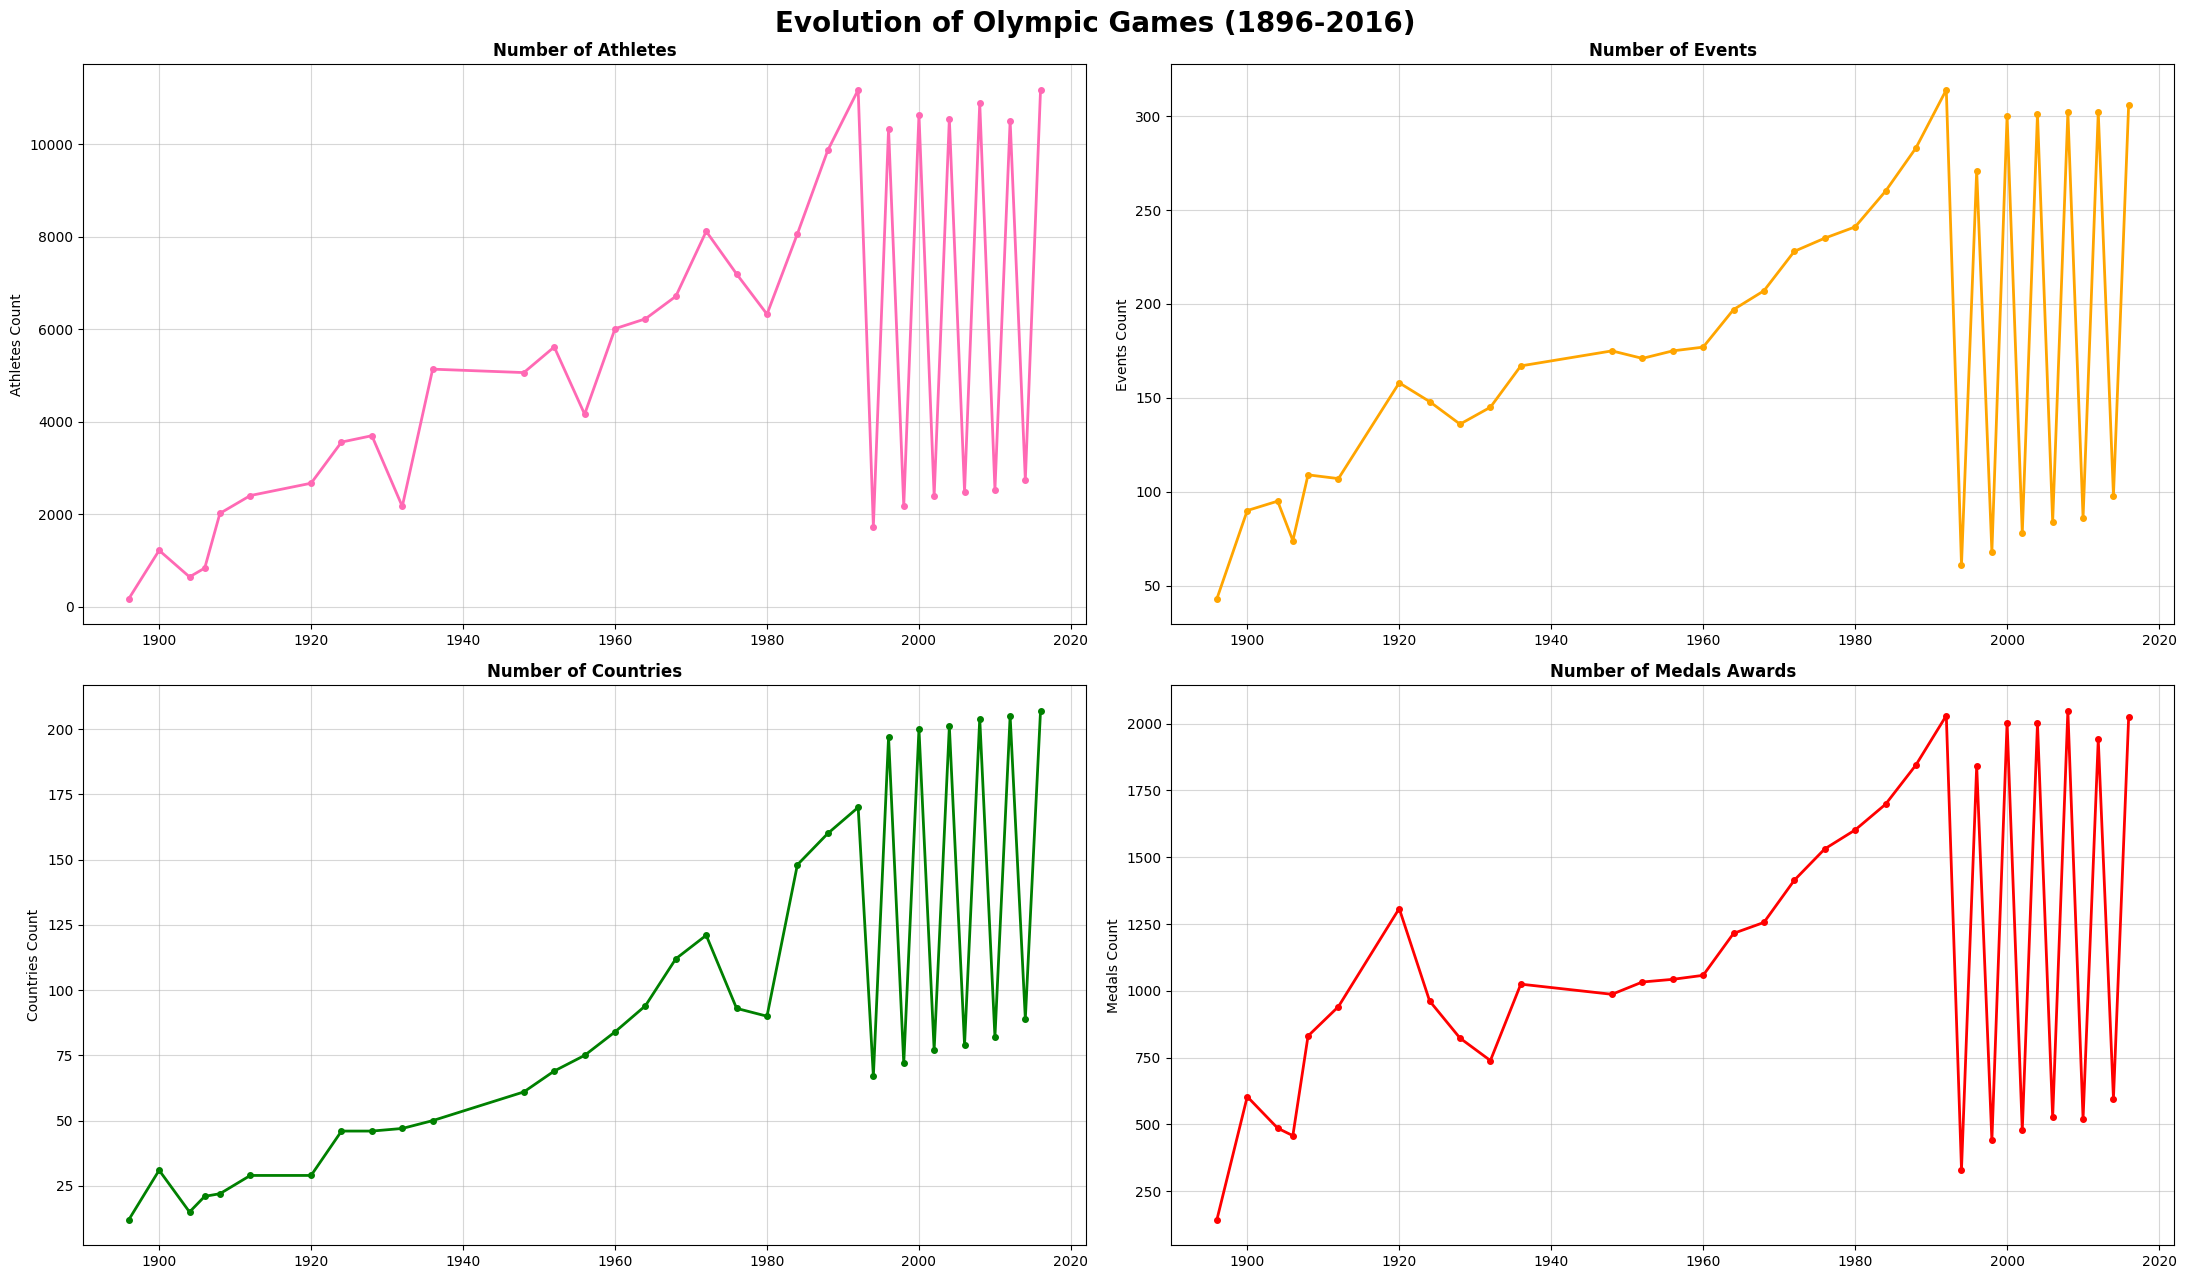

In [7]:
fig, axes = plt.subplots(2,2, figsize=(22,13))
fig.suptitle('Evolution of Olympic Games (1896-2016)', fontsize=20, fontweight='bold')

axes[0,0].plot(evoluation_stats.index, evoluation_stats["Athletes"], marker="o", linewidth=2, markersize=4, color="hotpink")
axes[0,0].set_title('Number of Athletes', fontweight='bold')
axes[0,0].set_ylabel('Athletes Count')
axes[0,0].grid(alpha=0.5)

axes[0,1].plot(evoluation_stats.index, evoluation_stats["Events"], marker="o", linewidth=2, markersize=4, color="Orange")
axes[0,1].set_title('Number of Events', fontweight='bold')
axes[0,1].set_ylabel('Events Count')
axes[0,1].grid(alpha=0.5)

axes[1,0].plot(evoluation_stats.index, evoluation_stats["Countries"], marker="o", linewidth=2, markersize=4, color="Green")
axes[1,0].set_title('Number of Countries', fontweight='bold')
axes[1,0].set_ylabel('Countries Count')
axes[1,0].grid(alpha=0.5)

axes[1,1].plot(evoluation_stats.index, evoluation_stats["Medals"], marker="o", linewidth=2, markersize=4, color="Red")
axes[1,1].set_title('Number of Medals Awards', fontweight='bold')
axes[1,1].set_ylabel('Medals Count')
axes[1,1].grid(alpha=0.5)

plt.tight_layout()
plt.show()

In [8]:
print("KEY INSIGHTS FROM EVOLUTION INSIGHT:")
print("=" * 50 + "\n")

print(f"Athletes increased from {evoluation_stats["Athletes"].min()} to {evoluation_stats["Athletes"].max():,}")
print(f"Events increased from {evoluation_stats["Events"].min()} to {evoluation_stats["Events"].max():,}")
print(f"Countries participation expanded from {evoluation_stats["Countries"].min()} to {evoluation_stats["Countries"].max():,}")

KEY INSIGHTS FROM EVOLUTION INSIGHT:

Athletes increased from 176 to 11,183
Events increased from 43 to 314
Countries participation expanded from 12 to 207


## Medals Distribution Analysis

In [9]:
medal_data = df_events[df_events["Medal"].notna()]
medal_data.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
37,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze
38,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze
40,16,Juhamatti Tapio Aaltonen,M,28.0,184.0,85.0,Finland,FIN,2014 Winter,2014,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze
41,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze


In [10]:
medal_count = medal_data["Medal"].value_counts()
medal_count

Medal
Gold      13372
Bronze    13295
Silver    13116
Name: count, dtype: int64

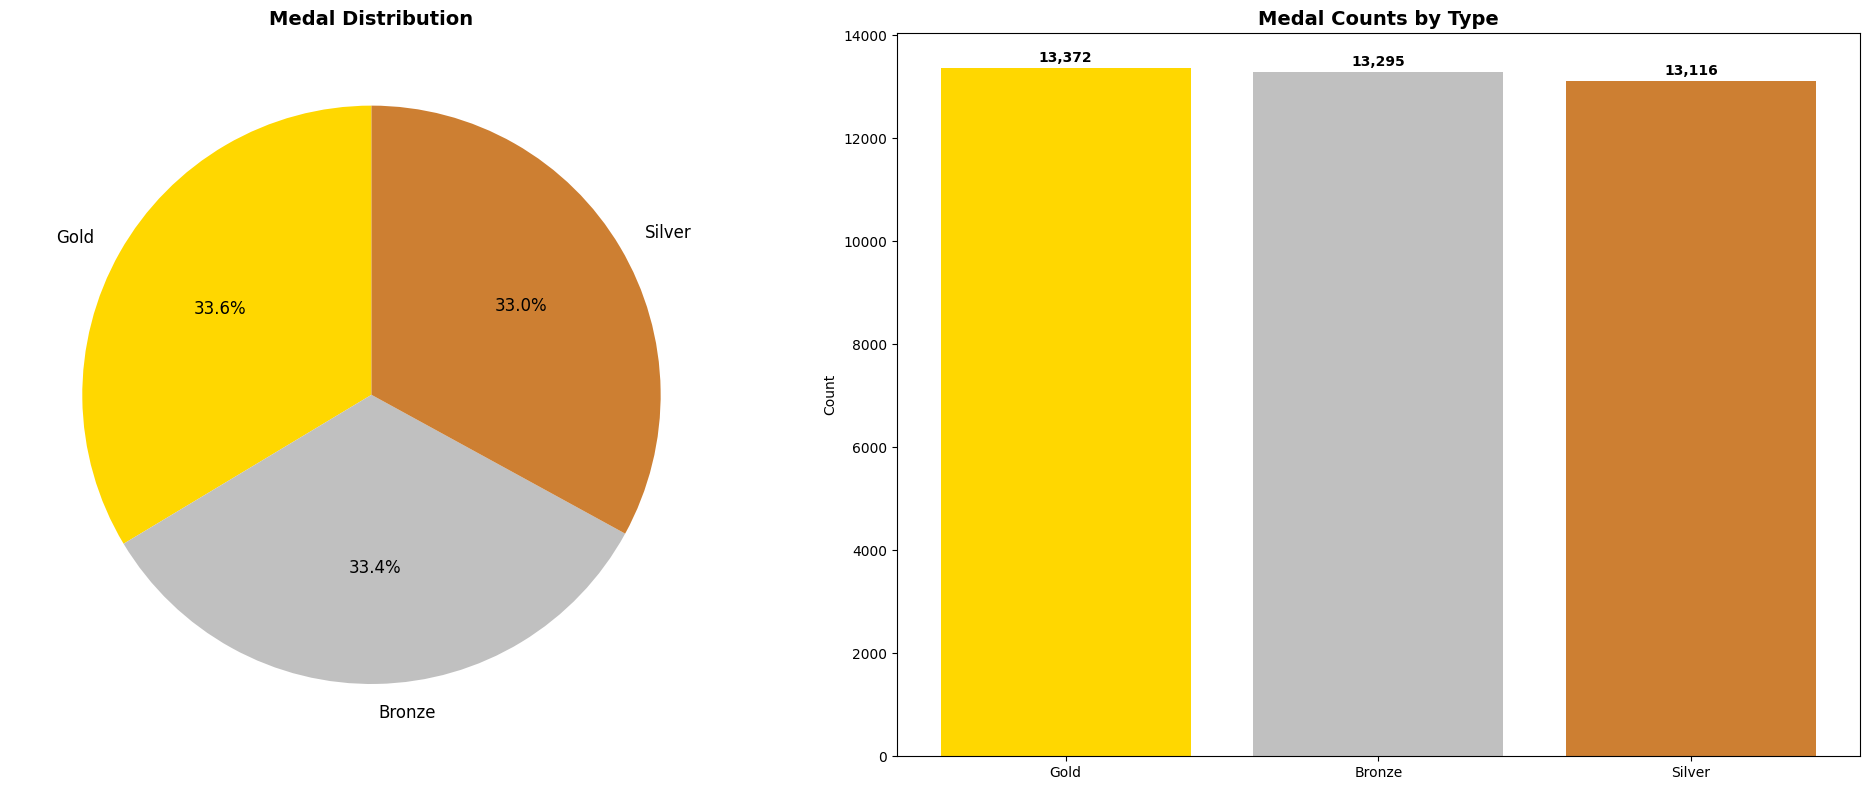

In [11]:
fig, axes = plt.subplots(1,2, figsize=(20,8))
colors = ['#FFD700', '#C0C0C0', '#CD7F32']  # Gold, Silver, Bronze colors

axes[0].pie(medal_count.values, labels=medal_count.index, colors=colors, autopct="%1.1f%%", textprops={"fontsize":12}, startangle=90)
axes[0].set_title('Medal Distribution', fontweight="bold", fontsize=14)

bars = axes[1].bar(medal_count.index, medal_count.values, color=colors)
axes[1].set_title('Medal Counts by Type', fontweight='bold', fontsize=14)
axes[1].set_xticklabels(medal_count.index)
axes[1].set_ylabel("Count")

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 50,
        f"{int(height):,}", fontweight="bold", va="bottom", ha="center")

plt.tight_layout()
plt.show()

In [12]:
print(f"Total Medals Awarded: {medal_count.sum()}\n")

for medal, count in medal_count.items():
    print(f"{medal}: {count} | ({count/medal_count.sum()*100:.1f}%)")

Total Medals Awarded: 39783

Gold: 13372 | (33.6%)
Bronze: 13295 | (33.4%)
Silver: 13116 | (33.0%)


## Top Performing Countries

In [13]:
country_medals = df_events[df_events["Medal"].notna()].groupby(["NOC", "Medal"]).size().unstack(fill_value=0)
country_medals["Total"] = country_medals.sum(axis=1)
country_medals = country_medals.sort_values("Total", ascending=False)

country_medals.head()

Medal,Bronze,Gold,Silver,Total
NOC,,,,
USA,1358,2638,1641,5637
URS,689,1082,732,2503
GER,746,745,674,2165
GBR,651,678,739,2068
FRA,666,501,610,1777


In [14]:
country_medals_with_names = country_medals.merge(df_noc[["NOC", "region"]],
                                                how="left", left_index=True, right_on="NOC")
country_medals_with_names.head()

,Bronze,Gold,Silver,Total,NOC,region
216.0,1358,2638,1641,5637,USA,USA
214.0,689,1082,732,2503,URS,Russia
79.0,746,745,674,2165,GER,Germany
74.0,651,678,739,2068,GBR,UK
69.0,666,501,610,1777,FRA,France


In [15]:
print("Find Empty Cells in Region\n")

display(country_medals_with_names[country_medals_with_names["region"].isna()])

print("="*50+"\n")

country_medals_with_names["Country"] = country_medals_with_names["region"].fillna(country_medals_with_names["NOC"])
country_medals_with_names.head()

Find Empty Cells in Region



,Bronze,Gold,Silver,Total,NOC,region
NaN,4,1,4,9,SGP,NaN


,Bronze,Gold,Silver,Total,NOC,region,Country
216.0,1358,2638,1641,5637,USA,USA,USA
214.0,689,1082,732,2503,URS,Russia,Russia
79.0,746,745,674,2165,GER,Germany,Germany
74.0,651,678,739,2068,GBR,UK,UK
69.0,666,501,610,1777,FRA,France,France


In [16]:
top_15_countries = country_medals_with_names.head(15)
top_15_countries.head()

,Bronze,Gold,Silver,Total,NOC,region,Country
216.0,1358,2638,1641,5637,USA,USA,USA
214.0,689,1082,732,2503,URS,Russia,Russia
79.0,746,745,674,2165,GER,Germany,Germany
74.0,651,678,739,2068,GBR,UK,UK
69.0,666,501,610,1777,FRA,France,France


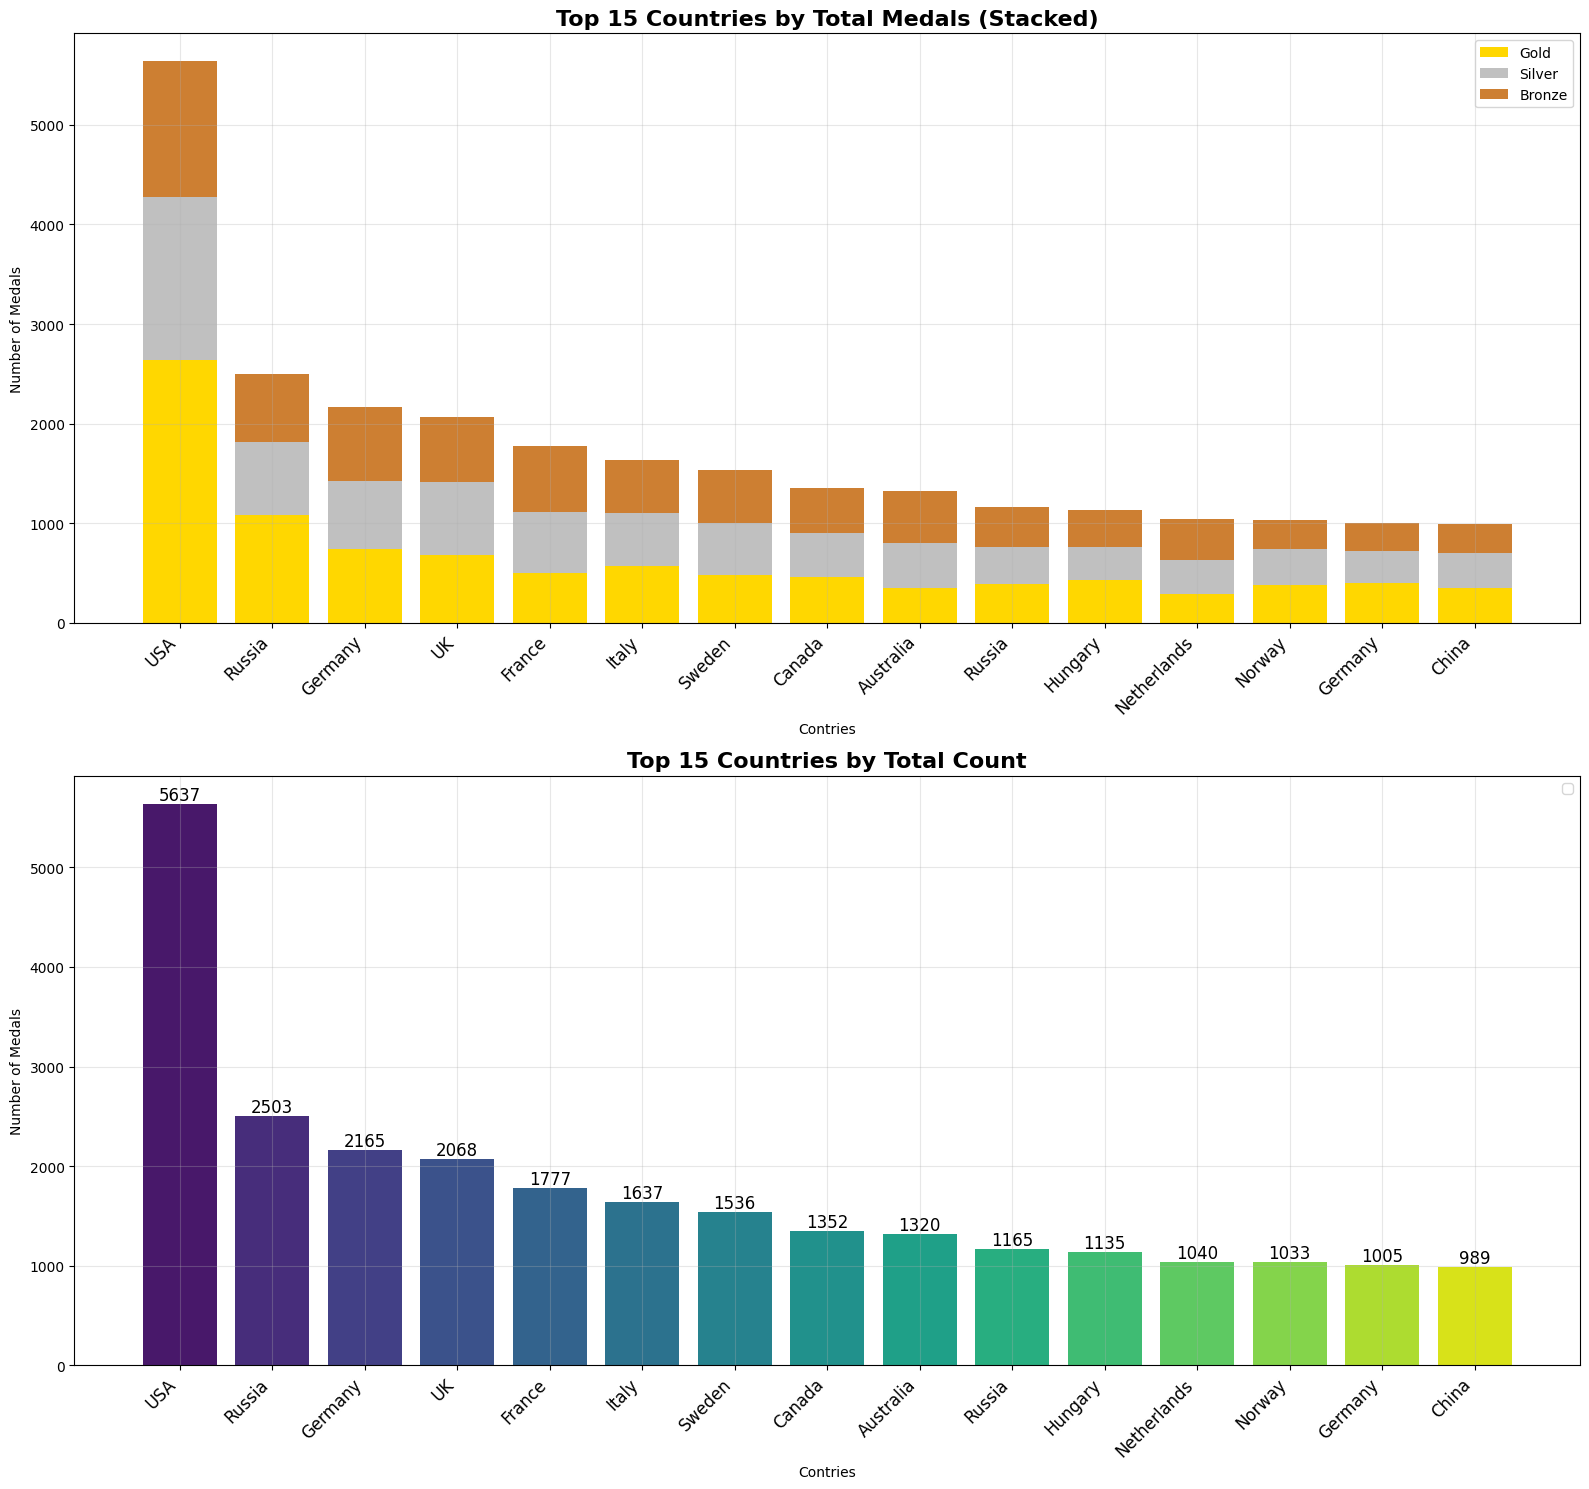

In [17]:
fig, axes = plt.subplots(2,1, figsize=(16,15))

# Stacked bar Chart for medal types
x_pos = np.arange(len(top_15_countries))
width= 0.8

p1 = axes[0].bar(x_pos, top_15_countries["Gold"], width, label="Gold", color="#FFD700")
p2 = axes[0].bar(x_pos, top_15_countries["Silver"], width,  bottom=top_15_countries['Gold'], 
                 label="Silver", color="#C0C0C0")
p3 = axes[0].bar(x_pos, top_15_countries["Bronze"], width, bottom=top_15_countries['Gold'] + top_15_countries['Silver'], 
                 label="Bronze", color="#CD7F32")


axes[0].set_title('Top 15 Countries by Total Medals (Stacked)', fontweight='bold', fontsize=16)
axes[0].set_xlabel("Contries")
axes[0].set_ylabel("Number of Medals")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(top_15_countries["Country"], fontsize=12, rotation=45, ha="right")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ---------------------------------------------------------------------------------------

bars = axes[1].bar(range(len(top_15_countries)), top_15_countries["Total"], 
            color=sns.color_palette("viridis", len(top_15_countries)))

axes[1].set_title('Top 15 Countries by Total Count', fontweight='bold', fontsize=16)
axes[1].set_xlabel("Contries")
axes[1].set_ylabel("Number of Medals")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(top_15_countries["Country"], fontsize=12, rotation=45, ha="right")
axes[1].legend()
axes[1].grid(True, alpha=0.3)


for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2, height, str(int(height)), 
                 ha='center', va='bottom', fontsize=12)
    

plt.tight_layout()
plt.show()

In [18]:
print("TOP 10 MEDAL-WINNING COUNTRIES:")
print("="*50)
top_15_countries[["Country", "Bronze", "Gold",	"Silver", "Total"]].head(10)

TOP 10 MEDAL-WINNING COUNTRIES:


,Country,Bronze,Gold,Silver,Total
216.0,USA,1358,2638,1641,5637
214.0,Russia,689,1082,732,2503
79.0,Germany,746,745,674,2165
74.0,UK,651,678,739,2068
69.0,France,666,501,610,1777
100.0,Italy,531,575,531,1637
193.0,Sweden,535,479,522,1536
36.0,Canada,451,463,438,1352
12.0,Australia,517,348,455,1320
171.0,Russia,408,390,367,1165


## Athlete Dmographics Analysis